# Traballo machine learning - Andrea Álvarez Penín, Luís Basanta Pérez
Importamos a base de datos de https://www.kaggle.com/datasets/shubham47/students-score-dataset-linear-regression

### Importamos librerías

In [1]:
import numpy as np
import pandas as pd

### Importamos o archivo de datos e mostrámolo

In [2]:
data = pd.read_csv('student_scores.csv') 
data

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


### Creamos diagrama de dispersión

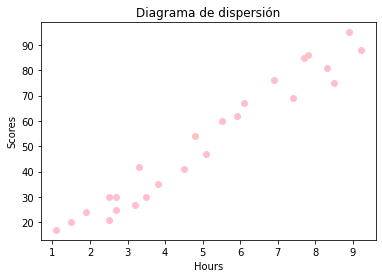

In [3]:
import matplotlib.pyplot as plt
plt.scatter(data['Hours'], data['Scores'], color='pink')
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Diagrama de dispersión")
plt.show()

### Preparamos os datos

In [4]:
X = data[['Hours']].values.reshape(-1,1) # Hours será a nosa variable explicatoria
Y = data['Scores'].values.reshape(-1,1) # Scores será a variable a predecir

print('X =', X.shape)
print('Y =', Y.shape)

X = (25, 1)
Y = (25, 1)


### Dividimos os conxuntos: train = 70% , test = 30%


In [5]:
from sklearn.model_selection import train_test_split

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.3, shuffle=True, random_state = 123)

train_Y = train_Y.reshape(-1)
test_Y = test_Y.reshape(-1)

print('X train = ', train_X.shape)
print('Y train = ', train_Y.shape)
print('X test  = ', test_X.shape)
print('Y test  = ', test_Y.shape)

X train =  (17, 1)
Y train =  (17,)
X test  =  (8, 1)
Y test  =  (8,)


### Extraemos variables individuais

In [6]:
train_X_Hours = train_X[:, 0].reshape(-1, 1)
test_X_Hours = test_X[:, 0].reshape(-1, 1)

print('X train Hours = ', train_X_Hours.shape)
print('X test Hours  = ', test_X_Hours.shape)

X train Hours =  (17, 1)
X test Hours  =  (8, 1)


### Creamos primeiro modelo de regresión : Scores ~ Hours

In [7]:
from sklearn.linear_model import LinearRegression

lm_1 = LinearRegression()  #obxecto para manexar regresión lineal
lm_1.fit(train_X_Hours, train_Y)  #creamos modelo

LinearRegression()

### Extraemos a pendente e o termo independente do modelo

In [8]:
pendente=lm_1.coef_
termo_indep=lm_1.intercept_
print('pendente= %.03f' % pendente)
print('termo independente= %.03f' % termo_indep)

pendente= 9.587
termo independente= 2.425


### Gráfica de regresión

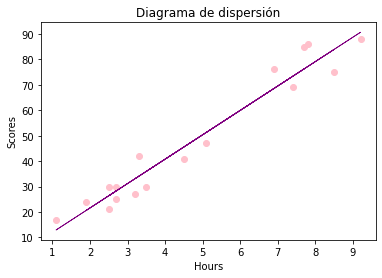

In [9]:
train_Y_predict = lm_1.predict(train_X_Hours)
plt.scatter(train_X_Hours, train_Y, color='pink')
plt.plot(train_X_Hours, train_Y_predict, color="purple", linewidth=0.8)
plt.xlabel("Hours")
plt.ylabel("Scores")
plt.title("Diagrama de dispersión")
plt.show()

### Evaluamos o valor de R^2 e RMSE (root-mean-square error)

In [10]:
R2 = lm_1.score(train_X_Hours, train_Y)
print('R^2 = %.02f' % R2)


import math
from sklearn import metrics

test_Y_predict = lm_1.predict(test_X_Hours)
MSE = metrics.mean_squared_error(test_Y, test_Y_predict) 
print('RMSE = %.02f' % math.sqrt(MSE))

R^2 = 0.95
RMSE = 4.73
